# 01 — Análise Exploratória do Fashion-MNIST

O **Fashion-MNIST** (Zalando) é um conjunto de 70.000 imagens em tons de cinza de
**peças de roupa**, cada uma com **28×28 pixels**: 60.000 para treino e 10.000 para
teste. Foi criado como um substituto *drop-in* do MNIST original — mesmo formato,
porém **mais difícil** e representativo de tarefas reais de visão computacional.

São 10 classes: Camiseta/top, Calça, Pulôver, Vestido, Casaco, Sandália, Camisa,
Tênis, Bolsa e Bota.

Objetivo desta análise: **conhecer os dados antes de modelar** — quantos exemplos
por classe, como são as imagens e qual a "cara média" de cada peça.

> Documentação complementar sobre o dataset em `docs/`.

## Identificação e descrição do problema

- **Título:** Classificação de Peças de Roupa com Fashion-MNIST (CNN e baselines clássicos)
- **Integrantes:** Arthur de Azevedo Grazzia e Rafael Rocha da Silva
- **Fonte dos dados:** [Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist),
  publicado pela Zalando Research; carregado automaticamente via
  `torchvision.datasets.FashionMNIST` (ver `src/utils.py`)
- **Objetivo:** treinar um modelo capaz de reconhecer, a partir da imagem, qual categoria de
  peça de roupa está sendo mostrada (ex.: distinguir uma camisa de um casaco)
- **Atributo-alvo:** a classe da peça de roupa — variável **categórica** com 10 valores
  possíveis (Camiseta/top, Calça, Pulôver, Vestido, Casaco, Sandália, Camisa, Tênis, Bolsa, Bota)
- **Atributos preditivos:** os 784 pixels da imagem (28×28, tons de cinza), tratados como
  atributos numéricos contínuos em [0, 1]
- **Tipo da tarefa:** **classificação multiclasse** (10 classes, mutuamente exclusivas)

In [1]:
# ── Setup — funciona igual no seu PC e no Google Colab ───────────────────────
# Ajuste REPO_URL após publicar o projeto no GitHub (ver README).
import sys, os, subprocess
from pathlib import Path

REPO_URL = "https://github.com/4rth-g/fashion-mnist-fundamentos-ia.git"

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # No Colab não há o repositório: clonamos para ter o código de src/ e as pastas.
    if not Path("fashion-mnist-fundamentos-ia").exists():
        subprocess.run(["git", "clone", REPO_URL], check=True)
    os.chdir("fashion-mnist-fundamentos-ia")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "seaborn"], check=True)

# Torna o pacote src/ importável (local: rodando de notebooks/; Colab: da raiz).
_root = Path.cwd()
_src = _root / "src" if (_root / "src").exists() else _root.parent / "src"
sys.path.insert(0, str(_src))
print("src/ em:", _src)

src/ em: /home/arthur-grazzia/Documentos/GitHub/fashion-mnist-fundamentos-ia/src


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from utils import load_fashion_mnist, seed_everything, CLASS_NAMES, FIGURES_DIR

sns.set_theme(style="whitegrid")
seed_everything()

# Carregamos SEM normalizar, para visualizar as imagens na escala natural (0–1).
train_full, test = load_fashion_mnist(normalize=False)
print(f"Treino: {len(train_full)} imagens | Teste: {len(test)} imagens")
print(f"Formato de uma imagem: {train_full[0][0].shape}  (canais × altura × largura)")
print(f"Classes: {CLASS_NAMES}")

Treino: 60000 imagens | Teste: 10000 imagens
Formato de uma imagem: torch.Size([1, 28, 28])  (canais × altura × largura)
Classes: ['Camiseta/top', 'Calça', 'Pulôver', 'Vestido', 'Casaco', 'Sandália', 'Camisa', 'Tênis', 'Bolsa', 'Bota']


## Quantidade de registros, atributos e qualidade dos dados

- **70.000 registros** no total: 60.000 imagens de treino + 10.000 de teste.
- **784 atributos por imagem** (28 × 28 pixels), todos do mesmo tipo: intensidade de cinza,
  contínua em [0, 1] após `ToTensor` (originalmente inteiros de 0 a 255).
- **1 atributo-alvo categórico**, com 10 classes (ver seção anterior).
- Diferente de um dataset tabular heterogêneo (com colunas de tipos distintos, texto, datas
  etc.), aqui todos os atributos são homogêneos — o desafio está na dimensionalidade (784
  atributos) e na estrutura espacial entre eles, não na heterogeneidade de tipos.

Antes de seguir para a exploração visual, verificamos explicitamente três problemas comuns de
qualidade de dados. Como o Fashion-MNIST é um benchmark padrão amplamente utilizado, não
esperamos encontrar problemas — mas confirmamos isso em vez de apenas assumir.

In [3]:
# Amostra para checagem rápida (checar as 70.000 imagens uma a uma seria lento e redundante).
sample_idxs = range(2000)
sample_imgs = np.stack([train_full[i][0].numpy() for i in sample_idxs])

# 1) Valores ausentes: cada imagem é um tensor denso, então "ausência" não é estruturalmente
# possível — mas verificamos explicitamente em vez de assumir.
n_nan = np.isnan(sample_imgs).sum()
print(f"Valores ausentes (NaN) em uma amostra de {len(sample_idxs)} imagens: {n_nan}")

# 2) Duplicatas: imagens idênticas byte-a-byte inflariam a contagem de exemplos "únicos" e,
# em outro contexto, poderiam vazar entre treino e teste.
flat_sample = sample_imgs.reshape(len(sample_imgs), -1)
n_unique = len(np.unique(flat_sample, axis=0))
dup_msg = "nenhuma duplicata" if n_unique == len(flat_sample) else f"{len(flat_sample) - n_unique} duplicata(s)"
print(f"Imagens únicas na amostra: {n_unique}/{len(flat_sample)} ({dup_msg})")

# 3) Inconsistências de rótulo: todo rótulo deve estar no intervalo esperado (0-9).
labels_all = train_full.targets.numpy()
n_invalid = int(((labels_all < 0) | (labels_all > 9)).sum())
print(f"Rótulos fora do intervalo esperado [0, 9] (nas {len(labels_all)} imagens de treino): {n_invalid}")

Valores ausentes (NaN) em uma amostra de 2000 imagens: 0
Imagens únicas na amostra: 2000/2000 (nenhuma duplicata)
Rótulos fora do intervalo esperado [0, 9] (nas 60000 imagens de treino): 0


## Distribuição das classes

Um dataset **balanceado** (classes com frequências parecidas) evita que o modelo
fique enviesado para as peças mais comuns. Vamos conferir.

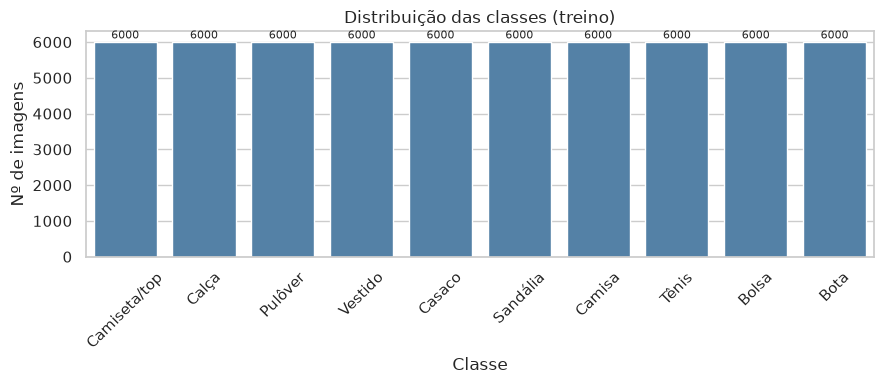

Menos frequente: Camiseta/top (6000) | Mais frequente: Camiseta/top (6000)
Fashion-MNIST é perfeitamente balanceado — 6.000 imagens por classe.


In [4]:
labels = train_full.targets.numpy()
counts = np.bincount(labels)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(x=CLASS_NAMES, y=counts, ax=ax, color="steelblue")
ax.set(title="Distribuição das classes (treino)", xlabel="Classe", ylabel="Nº de imagens")
ax.tick_params(axis="x", rotation=45)
for i, c in enumerate(counts):
    ax.text(i, c + 100, str(c), ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_distribuicao_classes.png", dpi=120)
plt.show()

print(f"Menos frequente: {CLASS_NAMES[counts.argmin()]} ({counts.min()}) | "
      f"Mais frequente: {CLASS_NAMES[counts.argmax()]} ({counts.max()})")
print("Fashion-MNIST é perfeitamente balanceado — 6.000 imagens por classe.")

## Amostras de cada classe

Como cada peça realmente se parece? Mostramos alguns exemplos por classe para
ter noção da **variação de estilos** dentro de cada categoria.

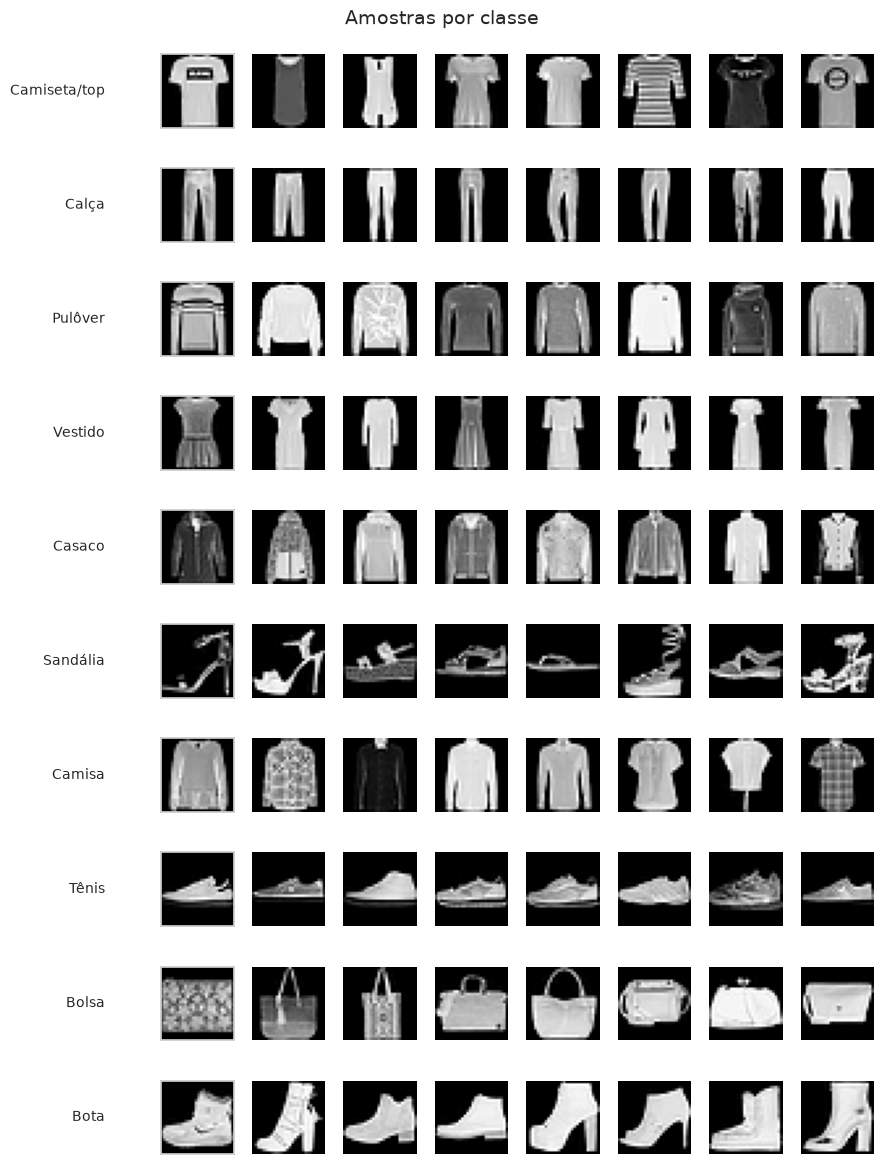

In [5]:
fig, axes = plt.subplots(10, 8, figsize=(9, 12))
for cls in range(10):
    idxs = np.where(labels == cls)[0][:8]
    for col, idx in enumerate(idxs):
        ax = axes[cls, col]
        ax.imshow(train_full[idx][0].squeeze(), cmap="gray")
        ax.axis("off")
    axes[cls, 0].set_ylabel(CLASS_NAMES[cls], rotation=0, labelpad=40,
                            fontsize=10, va="center", ha="right")
    axes[cls, 0].axis("on"); axes[cls, 0].set_xticks([]); axes[cls, 0].set_yticks([])
fig.suptitle("Amostras por classe", fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_amostras_por_classe.png", dpi=120)
plt.show()

## Imagem média de cada classe

Tirando a média de todas as imagens de uma classe, aparece um "protótipo" borrado.
Categorias com formas parecidas (como **Camiseta/top**, **Camisa**, **Pulôver** e
**Casaco**) geram protótipos semelhantes — uma pista de que serão as mais
confundidas pelo modelo depois.

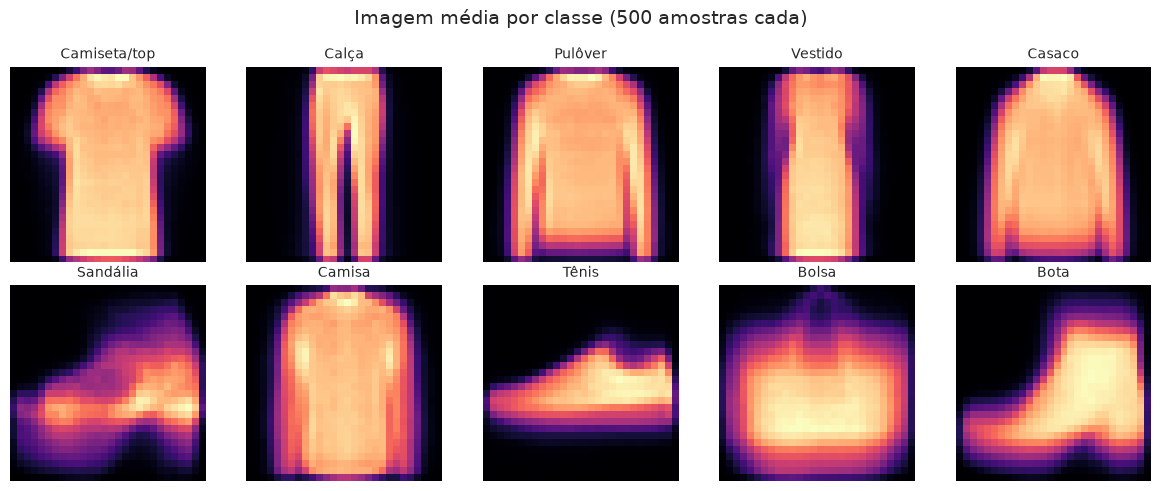

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for cls, ax in enumerate(axes.flat):
    mean_img = np.stack([train_full[i][0].numpy() for i in np.where(labels == cls)[0][:500]]).mean(0)
    ax.imshow(mean_img.squeeze(), cmap="magma")
    ax.set_title(CLASS_NAMES[cls], fontsize=10)
    ax.axis("off")
fig.suptitle("Imagem média por classe (500 amostras cada)", fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_media_por_classe.png", dpi=120)
plt.show()

## Medidas de localidade e dispersão da intensidade dos pixels

Além de contar exemplos e olhar imagens, vale caracterizar numericamente a
**intensidade dos pixels** (0 = preto, 1 = branco): tendência central, dispersão e
forma da distribuição — informação que também ajuda a justificar o escalonamento
aplicado no pré-processamento dos baselines clássicos (`00_baseline.ipynb`).

Média: 0.2839 | Desvio-padrão: 0.3535
Mínimo: 0.0000 | Q1: 0.0000 | Mediana: 0.0000 | Q3: 0.6431 | Máximo: 1.0000


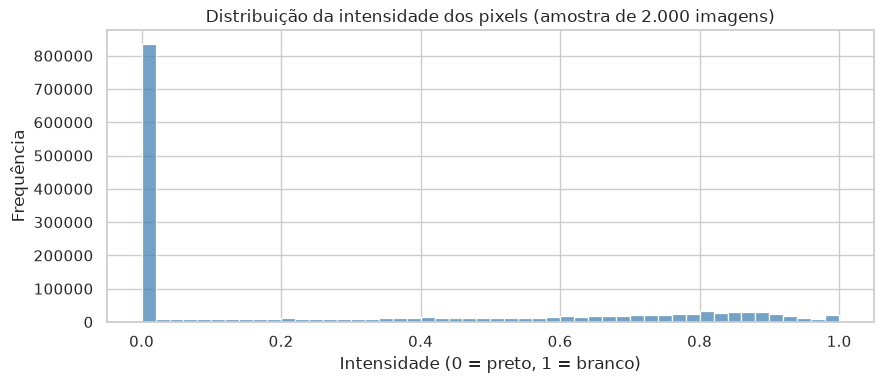

In [7]:
# Intensidade de cada pixel, achatada em um vetor único (reusa a amostra de 2.000
# imagens já carregada em `sample_imgs`, na seção de qualidade dos dados).
pixel_values = sample_imgs.reshape(-1)
q1, median, q3 = np.percentile(pixel_values, [25, 50, 75])
print(f"Média: {pixel_values.mean():.4f} | Desvio-padrão: {pixel_values.std():.4f}")
print(f"Mínimo: {pixel_values.min():.4f} | Q1: {q1:.4f} | Mediana: {median:.4f} | "
      f"Q3: {q3:.4f} | Máximo: {pixel_values.max():.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(pixel_values, bins=50, ax=ax, color="steelblue")
ax.set(title="Distribuição da intensidade dos pixels (amostra de 2.000 imagens)",
       xlabel="Intensidade (0 = preto, 1 = branco)", ylabel="Frequência")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_histograma_intensidade.png", dpi=120)
plt.show()

## Intensidade média por classe (boxplot)

Cada imagem tem uma **intensidade média** (média dos seus 784 pixels). Comparando
essa intensidade média entre classes com um boxplot, vemos se alguma categoria se
destaca por brilho global (ex.: peças claras vs. escuras) e se há sobreposição entre
as classes que a imagem média já sugeria serem parecidas (Camiseta/top, Camisa,
Pulôver, Casaco).

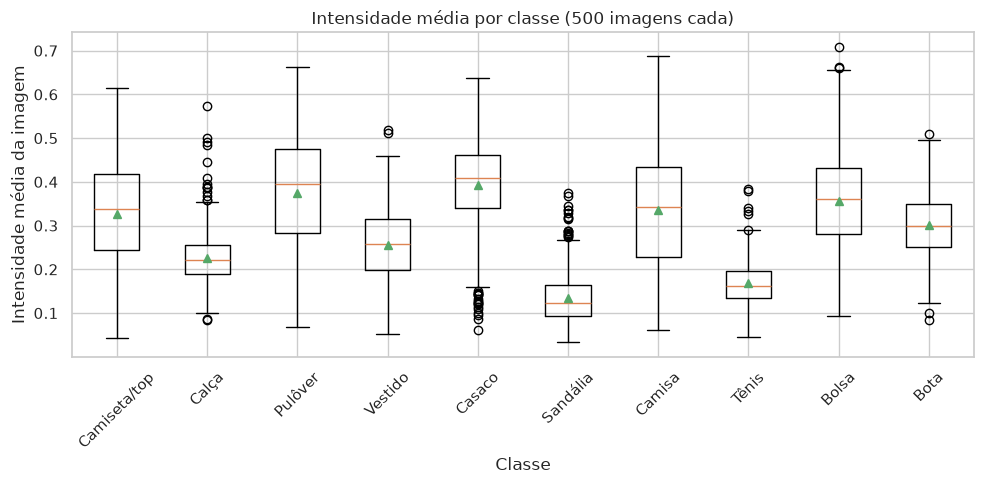

In [8]:
# Intensidade média de cada imagem (uma imagem = 784 pixels -> 1 valor escalar),
# agrupada por classe.
n_per_class_box = 500
box_data = []
for cls in range(10):
    idxs = np.where(labels == cls)[0][:n_per_class_box]
    imgs = np.stack([train_full[i][0].numpy() for i in idxs])
    box_data.append(imgs.reshape(len(idxs), -1).mean(axis=1))

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(box_data, tick_labels=CLASS_NAMES, showmeans=True)
ax.set(title=f"Intensidade média por classe ({n_per_class_box} imagens cada)",
       xlabel="Classe", ylabel="Intensidade média da imagem")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_boxplot_intensidade.png", dpi=120)
plt.show()

A distribuição de intensidade é fortemente assimétrica à direita: **mediana 0,0**
(a maior parte de cada imagem é fundo preto) e **Q3 ≈ 0,64**, com média 0,28 e desvio-
padrão 0,35 puxados pelos poucos pixels claros da peça em si. Isso é esperado — cada
peça ocupa só uma fração dos 28×28 pixels.

No boxplot por classe, **Casaco, Pulôver e Camisa** têm as maiores intensidades médias
(peças maiores/mais "cheias" no quadro), enquanto **Sandália e Tênis** têm as menores
(objetos pequenos, com bastante fundo preto ao redor) — coerente com calçados serem
historicamente mais fáceis de separar das demais classes nesse dataset.

## Correlação entre atributos

Uma correlação **pixel a pixel** (matriz 784×784) tecnicamente atende ao pedido do
enunciado, mas não é interpretável isoladamente — a maior parte da informação é só
redundância espacial local (um pixel e seu vizinho quase sempre têm intensidade
parecida). Para deixar essa análise **pertinente**, resumimos cada imagem em 4
regiões (quadrantes) e olhamos a correlação entre a intensidade média de cada uma —
uma versão de baixa dimensão, porém interpretável, da mesma pergunta.

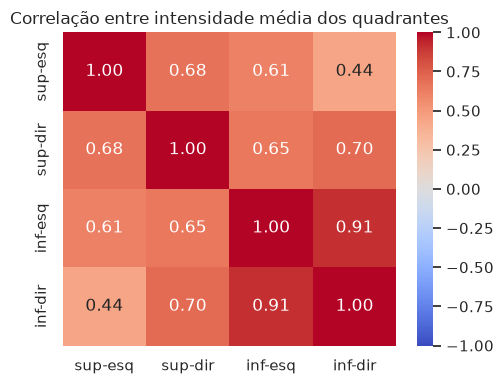

In [9]:
# Intensidade média de cada quadrante (14x14) para uma amostra de imagens.
n_corr_sample = 3000
rng = np.random.default_rng(42)
corr_idxs = rng.choice(len(train_full), size=n_corr_sample, replace=False)
imgs_corr = np.stack([train_full[i][0].numpy().squeeze() for i in corr_idxs])

quadrants = {
    "sup-esq": imgs_corr[:, :14, :14].mean(axis=(1, 2)),
    "sup-dir": imgs_corr[:, :14, 14:].mean(axis=(1, 2)),
    "inf-esq": imgs_corr[:, 14:, :14].mean(axis=(1, 2)),
    "inf-dir": imgs_corr[:, 14:, 14:].mean(axis=(1, 2)),
}
quad_names = list(quadrants.keys())
quad_matrix = np.stack([quadrants[k] for k in quad_names])
corr = np.corrcoef(quad_matrix)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt=".2f", xticklabels=quad_names,
            yticklabels=quad_names, cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlação entre intensidade média dos quadrantes")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_correlacao_quadrantes.png", dpi=120)
plt.show()

As correlações são todas positivas e moderadas a fortes (0,44 a 0,91) — regiões
vizinhas da imagem tendem a estar "cheias" ou "vazias" juntas, como esperado para
silhuetas de roupas contínuas. A correlação mais forte é entre os quadrantes
**inferiores** (0,91) — faz sentido: a parte de baixo da imagem costuma ser dominada
por uma única peça (perna da calça, corpo do vestido, sola do calçado) que ocupa os
dois lados de forma parecida. A mais fraca é entre os quadrantes **diagonalmente
opostos** (sup-esq × inf-dir, 0,44), que capturam partes mais independentes da peça
(ex.: gola vs. barra).

## Gráfico de dispersão (PCA 2D)

Um scatter dos 784 atributos brutos, dois a dois, não faria sentido (não há um par
de pixels naturalmente especial). Em vez disso, projetamos as imagens em 2 componentes
principais (PCA) e usamos isso como o "gráfico de dispersão" — cada ponto é uma
imagem inteira, colorida pela classe verdadeira, o que ajuda a visualizar a **relação
entre os atributos (em conjunto) e o alvo**.

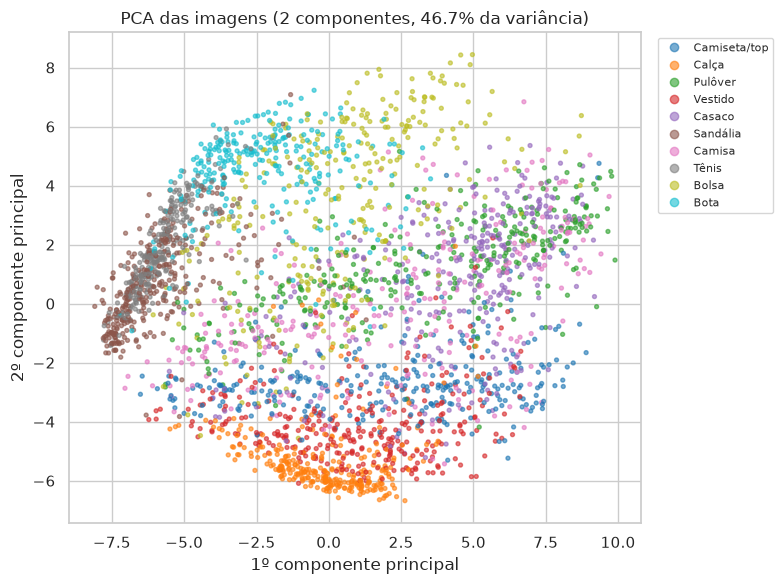

In [10]:
from sklearn.decomposition import PCA

flat_corr = imgs_corr.reshape(n_corr_sample, -1)
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(flat_corr)
corr_labels = np.array([train_full.targets[i].item() for i in corr_idxs])

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=corr_labels, cmap="tab10", s=8, alpha=0.6)
handles, _ = scatter.legend_elements(num=10)
ax.legend(handles, CLASS_NAMES, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.set(title=f"PCA das imagens (2 componentes, {pca.explained_variance_ratio_.sum():.1%} da variância)",
       xlabel="1º componente principal", ylabel="2º componente principal")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_pca_dispersao.png", dpi=120)
plt.show()

Mesmo com só **46,7% da variância** capturada em 2 componentes, o padrão já é claro:

- **Calçados (Sandália, Tênis, Bota)** formam um agrupamento bem separado no canto
  superior/central esquerdo — silhuetas pequenas e muito distintas das demais.
- **Calça e Vestido** ficam concentrados na parte inferior do gráfico, também bem
  isolados.
- **Camiseta/top, Pulôver, Casaco e Camisa** (as peças "de tronco") se sobrepõem
  fortemente no centro/direita — exatamente as classes que a imagem média (seção
  anterior) já sugeria serem parecidas, e que a CNN (`02_cnn.ipynb`) mais confunde
  entre si na prática.

Ou seja, só com 2 componentes principais já dá pra prever boa parte de onde o modelo
vai ter mais e menos dificuldade.

## Valores extremos e atributos irrelevantes

**Valores extremos (outliers):** cada atributo (pixel) já é limitado por construção a
[0, 1] — não existe o equivalente a um "salário negativo" ou "idade de 300 anos" aqui,
então a noção clássica de outlier por atributo não se aplica diretamente. O que faz
sentido checar é se existem **imagens inteiras atípicas** (ex.: quase todas pretas ou
quase todas brancas), o que indicaria erro de captura/rótulo.

**Atributos irrelevantes:** nem todo pixel carrega informação — os pixels de canto
quase sempre são fundo preto em toda imagem, então têm variância próxima de zero entre
as 60 mil imagens de treino.

Imagens com intensidade média a mais de 3 desvios-padrão da média geral: 37 de 60000 (0.06%)


Pixels com variância < 1e-4 entre as 60000 imagens de treino: 1.4% do total de 784 atributos


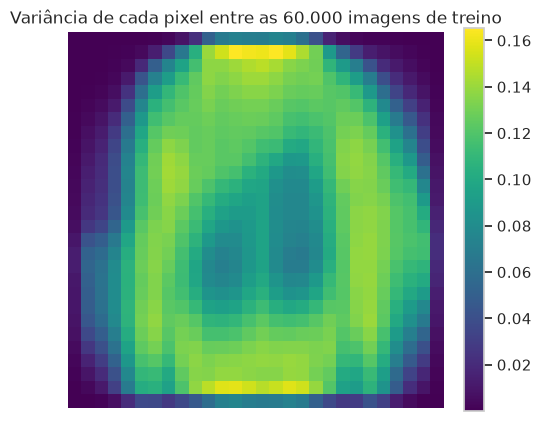

In [11]:
# Imagens atípicas: intensidade média muito fora do range típico (>3 desvios-padrão).
all_means = np.array([train_full[i][0].numpy().mean() for i in range(len(train_full))])
z = (all_means - all_means.mean()) / all_means.std()
n_atypical = int((np.abs(z) > 3).sum())
print(f"Imagens com intensidade média a mais de 3 desvios-padrão da média geral: "
      f"{n_atypical} de {len(train_full)} ({n_atypical / len(train_full):.2%})")

# Variância por pixel (atributo) em todo o treino -> mapa 28x28 de quais pixels
# carregam pouca informação.
all_imgs = np.stack([train_full[i][0].numpy().squeeze() for i in range(len(train_full))])
pixel_var = all_imgs.var(axis=0)
low_var_frac = (pixel_var < 1e-4).mean()
print(f"Pixels com variância < 1e-4 entre as {len(train_full)} imagens de treino: "
      f"{low_var_frac:.1%} do total de 784 atributos")

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(pixel_var, cmap="viridis")
ax.set_title("Variância de cada pixel entre as 60.000 imagens de treino")
ax.axis("off")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_variancia_pixels.png", dpi=120)
plt.show()

Nenhum dos dois problemas é relevante o suficiente para exigir tratamento:

- **Apenas 37 imagens (0,06%)** têm intensidade média a mais de 3 desvios-padrão da
  média geral — não removemos porque continuam sendo peças de roupa válidas (só mais
  claras/escuras que a média), não erros de captura.
- **Apenas 1,4% dos 784 pixels** têm variância menor que 1e-4 entre as 60 mil imagens —
  concentrados nos **cantos** do mapa de variância acima, onde é sempre fundo preto.
  Mantivemos esses pixels sem remoção: é uma fração pequena demais para valer a
  complexidade de um passo de seleção de atributos, e tanto os baselines
  (`RandomForestClassifier` naturalmente ignora atributos pouco informativos) quanto a
  CNN (convolução local não é afetada por alguns pixels de canto constantes) lidam bem
  com isso sem ajuda extra.

## Conclusões da EDA

- **70.000 imagens 28×28** em tons de cinza (784 atributos por imagem), 10 classes de peças
  de roupa.
- Dataset **perfeitamente balanceado** (6.000 por classe) → acurácia é uma métrica adequada.
- **Sem valores ausentes, duplicatas ou rótulos inconsistentes** na amostra verificada — um
  dataset de qualidade, como esperado de um benchmark consolidado.
- A **intensidade média por pixel** é assimétrica à direita (mediana 0,0, Q3 ≈
  0,64) — a maior parte de cada imagem é fundo preto. Por classe, calçados
  (Sandália, Tênis) têm as menores intensidades médias e peças "de tronco"
  maiores (Casaco, Pulôver, Camisa) as maiores.
- Há **variação de estilo** dentro de cada categoria; as imagens médias sugerem que os artigos
  "de tronco" (Camiseta/top, Camisa, Pulôver, Casaco) podem ser mais confundidos entre si.
- **PCA em 2D** já separa bem calçados e Calça/Vestido do resto; as peças "de
  tronco" continuam sobrepostas — reforça a expectativa de que serão as mais
  confundidas pelo modelo.
- **Sem valores extremos relevantes** (0,06% de imagens atípicas) e só **1,4% dos
  pixels** com variância praticamente nula (cantos/fundo) — nenhum tratamento de
  outlier ou seleção de atributos foi necessário.
- Próximos passos: `00_baseline.ipynb` treina os modelos clássicos mínimos exigidos
  (SGDClassifier, RandomForestClassifier); `02_cnn.ipynb` treina a CNN, o modelo principal
  do projeto.